# Single-Factor Vasicek Model

We first calibrate and simulate a univariate Vasicek model for the 6-month US Treasury yield.

The Vasicek model is:

$$
dr_t = \kappa(\theta-r_t)dt+\sigma dW_t
$$

where:

- $\kappa$ is the speed of mean reversion
- $\theta$ is the long-run mean
- $\sigma$ is the instantaneous annual volatility
- $r_t$ is the yield at time $t$    

In [68]:
#Import the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.stats import probplot

In [25]:
df = pd.read_csv("../data/processed/cleaned_yield_curve.csv")

df.head()

,Date,6M,1Y,2Y,3Y,5Y,7Y,10Y
0,1990-01-02,7.89,7.81,7.87,7.90,7.87,7.98,7.94
1,1990-01-03,7.94,7.85,7.94,7.96,7.92,8.04,7.99
2,1990-01-04,7.90,7.82,7.92,7.93,7.91,8.02,7.98
3,1990-01-05,7.85,7.79,7.90,7.94,7.92,8.03,7.99
4,1990-01-08,7.88,7.81,7.90,7.95,7.92,8.05,8.02


Now we have a look at only the 6 month maturities, since this is a single factor model.

In [26]:
vasicek_6m = df[
    ["Date", "6M"]
].copy()

vasicek_6m.head()

,Date,6M
0,1990-01-02,7.89
1,1990-01-03,7.94
2,1990-01-04,7.90
3,1990-01-05,7.85
4,1990-01-08,7.88


In [27]:
vasicek_6m["Date"] = pd.to_datetime(
    vasicek_6m["Date"],
    errors="coerce"
)

vasicek_6m["6M"] = pd.to_numeric(
    vasicek_6m["6M"],
    errors="coerce"
)

vasicek_6m = (
    vasicek_6m
    .dropna()
    .sort_values("Date")
    .drop_duplicates(subset="Date")
    .reset_index(drop=True)
)

vasicek_6m.head()

,Date,6M
0,1990-01-02,7.89
1,1990-01-03,7.94
2,1990-01-04,7.90
3,1990-01-05,7.85
4,1990-01-08,7.88


In [28]:
print(
    "Number of observations:",
    len(vasicek_6m)
)

print(
    "Starting date:",
    vasicek_6m["Date"].min()
)

print(
    "Ending date:",
    vasicek_6m["Date"].max()
)

print(
    "Missing values:"
)

print(
    vasicek_6m.isna().sum()
)

Number of observations: 8506
Starting date: 1990-01-02 00:00:00
Ending date: 2023-12-29 00:00:00
Missing values:
Date    0
6M      0
dtype: int64


In [29]:
print(
    "Duplicated dates:",
    vasicek_6m["Date"].duplicated().sum()
)

Duplicated dates: 0


In [30]:
vasicek_6m["Rate"] = (
    vasicek_6m["6M"] / 100
)

vasicek_6m.head()

,Date,6M,Rate
0,1990-01-02,7.89,0.0789
1,1990-01-03,7.94,0.0794
2,1990-01-04,7.90,0.0790
3,1990-01-05,7.85,0.0785
4,1990-01-08,7.88,0.0788


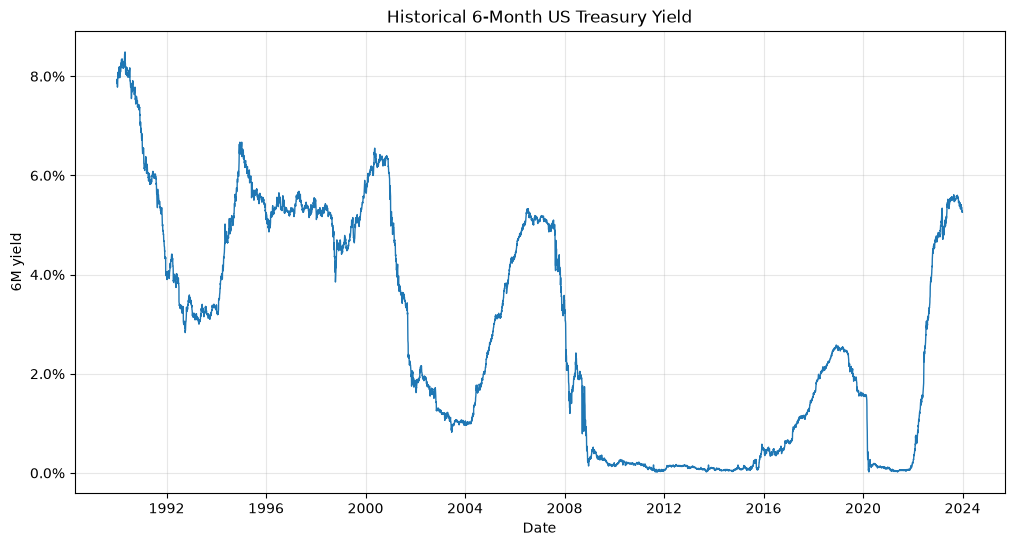

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(
    vasicek_6m["Date"],
    vasicek_6m["Rate"],
    linewidth=1
)

plt.title(
    "Historical 6-Month US Treasury Yield"
)

plt.xlabel("Date")
plt.ylabel("6M yield")

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.grid(alpha=0.3)
plt.show()

In [32]:
vasicek_6m["Rate"]

0       0.0789
1       0.0794
2       0.0790
3       0.0785
4       0.0788
         ...  
8501    0.0531
8502    0.0528
8503    0.0526
8504    0.0528
8505    0.0526
Name: Rate, Length: 8506, dtype: float64

In [33]:
vasicek_6m["Next_Date"] = (
    vasicek_6m["Date"].shift(-1)
)

vasicek_6m["Next_Rate"] = (
    vasicek_6m["Rate"].shift(-1)
)

vasicek_6m.head()

,Date,6M,Rate,Next_Date,Next_Rate
0,1990-01-02,7.89,0.0789,1990-01-03,0.0794
1,1990-01-03,7.94,0.0794,1990-01-04,0.0790
2,1990-01-04,7.90,0.0790,1990-01-05,0.0785
3,1990-01-05,7.85,0.0785,1990-01-08,0.0788
4,1990-01-08,7.88,0.0788,1990-01-09,0.0782


In [34]:
vasicek_6m["Calendar_Days"] = (
    vasicek_6m["Next_Date"]
    - vasicek_6m["Date"]
).dt.days

vasicek_6m[
    [
        "Date",
        "Next_Date",
        "Calendar_Days"
    ]
].head(10)

,Date,Next_Date,Calendar_Days
0,1990-01-02,1990-01-03,1.0
1,1990-01-03,1990-01-04,1.0
2,1990-01-04,1990-01-05,1.0
3,1990-01-05,1990-01-08,3.0
4,1990-01-08,1990-01-09,1.0
5,1990-01-09,1990-01-10,1.0
6,1990-01-10,1990-01-11,1.0
7,1990-01-11,1990-01-12,1.0
8,1990-01-12,1990-01-16,4.0
9,1990-01-16,1990-01-17,1.0


In [35]:
vasicek_6m["Delta_t"] = (
    vasicek_6m["Calendar_Days"] / 365.25
)

In [36]:
transitions_6m = vasicek_6m[
    [
        "Date",
        "Next_Date",
        "Rate",
        "Next_Rate",
        "Calendar_Days",
        "Delta_t"
    ]
].dropna().copy()

transitions_6m = transitions_6m[
    transitions_6m["Delta_t"] > 0
].reset_index(drop=True)

transitions_6m.head()

,Date,Next_Date,Rate,Next_Rate,Calendar_Days,Delta_t
0,1990-01-02,1990-01-03,0.0789,0.0794,1.0,0.002738
1,1990-01-03,1990-01-04,0.0794,0.0790,1.0,0.002738
2,1990-01-04,1990-01-05,0.0790,0.0785,1.0,0.002738
3,1990-01-05,1990-01-08,0.0785,0.0788,3.0,0.008214
4,1990-01-08,1990-01-09,0.0788,0.0782,1.0,0.002738


In [37]:
transitions_6m = transitions_6m.rename(
    columns={
        "Rate": "r_t",
        "Next_Rate": "r_next"
    }
)

transitions_6m.head()

,Date,Next_Date,r_t,r_next,Calendar_Days,Delta_t
0,1990-01-02,1990-01-03,0.0789,0.0794,1.0,0.002738
1,1990-01-03,1990-01-04,0.0794,0.0790,1.0,0.002738
2,1990-01-04,1990-01-05,0.0790,0.0785,1.0,0.002738
3,1990-01-05,1990-01-08,0.0785,0.0788,3.0,0.008214
4,1990-01-08,1990-01-09,0.0788,0.0782,1.0,0.002738


In [38]:
print(
    "Number of transitions:",
    len(transitions_6m)
)

print(
    "Minimum time step:",
    transitions_6m["Delta_t"].min()
)

print(
    "Maximum time step:",
    transitions_6m["Delta_t"].max()
)

print(
    "Missing values:"
)

print(
    transitions_6m.isna().sum()
)

Number of transitions: 8505
Minimum time step: 0.0027378507871321013
Maximum time step: 0.010951403148528405
Missing values:
Date             0
Next_Date        0
r_t              0
r_next           0
Calendar_Days    0
Delta_t          0
dtype: int64


In [39]:
transitions_6m[
    "Calendar_Days"
].value_counts().sort_index().head(15)

Calendar_Days
1.0    6637
2.0      94
3.0    1507
4.0     267
Name: count, dtype: int64

In [40]:
transitions_6m

,Date,Next_Date,r_t,r_next,Calendar_Days,Delta_t
0,1990-01-02,1990-01-03,0.0789,0.0794,1.0,0.002738
1,1990-01-03,1990-01-04,0.0794,0.0790,1.0,0.002738
2,1990-01-04,1990-01-05,0.0790,0.0785,1.0,0.002738
3,1990-01-05,1990-01-08,0.0785,0.0788,3.0,0.008214
4,1990-01-08,1990-01-09,0.0788,0.0782,1.0,0.002738
...,...,...,...,...,...,...
8500,2023-12-21,2023-12-22,0.0531,0.0531,1.0,0.002738
8501,2023-12-22,2023-12-26,0.0531,0.0528,4.0,0.010951
8502,2023-12-26,2023-12-27,0.0528,0.0526,1.0,0.002738
8503,2023-12-27,2023-12-28,0.0526,0.0528,1.0,0.002738


In [41]:
#Important columns

transitions_6m["r_t"]
transitions_6m["r_next"]
transitions_6m["Delta_t"]

0       0.002738
1       0.002738
2       0.002738
3       0.008214
4       0.002738
          ...   
8500    0.002738
8501    0.010951
8502    0.002738
8503    0.002738
8504    0.002738
Name: Delta_t, Length: 8505, dtype: float64

In [42]:
r_t = transitions_6m["r_t"].to_numpy(
    dtype=float
)

r_next = transitions_6m["r_next"].to_numpy(
    dtype=float
)

delta_t = transitions_6m["Delta_t"].to_numpy(
    dtype=float
)

print("Number of transitions:", len(r_t))
print("First current rate:", r_t[0])
print("First next rate:", r_next[0])
print("First time step:", delta_t[0])

Number of transitions: 8505
First current rate: 0.0789
First next rate: 0.0794
First time step: 0.0027378507871321013


In [46]:
def vasicek_negative_log_likelihood(
    parameters,
    r_t,
    r_next,
    delta_t
):
    log_kappa, theta, log_sigma = parameters

    kappa = np.exp(log_kappa)
    sigma = np.exp(log_sigma)

    phi = np.exp(-kappa * delta_t)

    conditional_mean = (
        theta
        + (r_t - theta) * phi
    )

    conditional_variance = (
        sigma ** 2
        * (1 - phi ** 2)
        / (2 * kappa)
    )

    if np.any(conditional_variance <= 0):
        return np.inf

    residuals = (
        r_next - conditional_mean
    )

    log_likelihood_terms = (
        -0.5
        * (
            np.log(
                2
                * np.pi
                * conditional_variance
            )
            +
            residuals ** 2
            / conditional_variance
        )
    )

    total_log_likelihood = np.sum(
        log_likelihood_terms
    )

    return -total_log_likelihood

In [47]:
theta_initial = r_t.mean()

kappa_initial = 0.50

sigma_initial = np.sqrt(
    np.sum((r_next - r_t) ** 2)
    /
    np.sum(delta_t)
)

print(
    "Initial kappa:",
    kappa_initial
)

print(
    "Initial theta:",
    theta_initial
)

print(
    "Initial sigma:",
    sigma_initial
)

Initial kappa: 0.5
Initial theta: 0.02810388007054674
Initial sigma: 0.006516163446082803


In [48]:
initial_parameters = np.array([
    np.log(kappa_initial),
    theta_initial,
    np.log(sigma_initial)
])

initial_parameters

array([-0.69314718,  0.02810388, -5.0334695 ])

In [49]:
#Now we run the MLE

mle_result_6m = minimize(
    vasicek_negative_log_likelihood,
    x0=initial_parameters,
    args=(
        r_t,
        r_next,
        delta_t
    ),
    method="L-BFGS-B",
    bounds=[
        (
            np.log(0.000001),
            np.log(10)
        ),
        (
            -0.10,
            0.20
        ),
        (
            np.log(0.000001),
            np.log(1)
        )
    ]
)

In [50]:
print(
    "Optimization successful:",
    mle_result_6m.success
)

print(
    "Optimizer message:",
    mle_result_6m.message
)

print(
    "Negative log-likelihood:",
    mle_result_6m.fun
)

Optimization successful: True
Optimizer message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Negative log-likelihood: -54296.503488552684


In [53]:
log_kappa_6m, theta_6m, log_sigma_6m = (
    mle_result_6m.x
)

kappa_6m = np.exp(
    log_kappa_6m
)

sigma_6m = np.exp(
    log_sigma_6m
)

In [54]:
print(
    f"Kappa: {kappa_6m:.6f}"
)

print(
    f"Theta: {theta_6m:.4%}"
)

print(
    f"Sigma: {sigma_6m:.4%}"
)

Kappa: 0.097983
Theta: 2.0198%
Sigma: 0.6905%


In [55]:
half_life_years_6m = (
    np.log(2)
    /
    kappa_6m
)

print(
    f"Half-life: "
    f"{half_life_years_6m:.2f} years"
)

Half-life: 7.07 years


In [56]:
parameters_6m = pd.Series({
    "Maturity": "6M",
    "Kappa": kappa_6m,
    "Theta": theta_6m,
    "Theta_Percent": theta_6m * 100,
    "Sigma": sigma_6m,
    "Sigma_Percent": sigma_6m * 100,
    "Half_Life_Years":
        half_life_years_6m,
    "Log_Likelihood":
        -mle_result_6m.fun,
    "Optimization_Success":
        mle_result_6m.success
})

parameters_6m

Maturity                          6M
Kappa                       0.097983
Theta                       0.020198
Theta_Percent               2.019778
Sigma                       0.006905
Sigma_Percent               0.690546
Half_Life_Years             7.074164
Log_Likelihood          54296.503489
Optimization_Success            True
dtype: object

In [57]:
print(
    "Kappa at boundary:",
    np.isclose(kappa_6m, 0.000001)
    or np.isclose(kappa_6m, 10)
)

print(
    "Theta at boundary:",
    np.isclose(theta_6m, -0.10)
    or np.isclose(theta_6m, 0.20)
)

print(
    "Sigma at boundary:",
    np.isclose(sigma_6m, 0.000001)
    or np.isclose(sigma_6m, 1)
)

Kappa at boundary: False
Theta at boundary: False
Sigma at boundary: False


In [58]:
phi_6m = np.exp(
    -kappa_6m * delta_t
)

fitted_mean_6m = (
    theta_6m
    + (r_t - theta_6m) * phi_6m
)

In [59]:
fitted_variance_6m = (
    sigma_6m ** 2
    * (1 - phi_6m ** 2)
    / (2 * kappa_6m)
)

fitted_sd_6m = np.sqrt(
    fitted_variance_6m
)

In [60]:
residuals_6m = (
    r_next - fitted_mean_6m
)

standardized_residuals_6m = (
    residuals_6m
    / fitted_sd_6m
)

In [61]:
validation_6m = transitions_6m.copy()

validation_6m[
    "Fitted_Mean"
] = fitted_mean_6m

validation_6m[
    "Fitted_SD"
] = fitted_sd_6m

validation_6m[
    "Residual"
] = residuals_6m

validation_6m[
    "Standardized_Residual"
] = standardized_residuals_6m

validation_6m.head()

,Date,Next_Date,r_t,r_next,Calendar_Days,Delta_t,Fitted_Mean,Fitted_SD,Residual,Standardized_Residual
0,1990-01-02,1990-01-03,0.0789,0.0794,1.0,0.002738,0.078884,0.000361,0.000516,1.427566
1,1990-01-03,1990-01-04,0.0794,0.0790,1.0,0.002738,0.079384,0.000361,-0.000384,-1.063232
2,1990-01-04,1990-01-05,0.0790,0.0785,1.0,0.002738,0.078984,0.000361,-0.000484,-1.340326
3,1990-01-05,1990-01-08,0.0785,0.0788,3.0,0.008214,0.078453,0.000626,0.000347,0.554528
4,1990-01-08,1990-01-09,0.0788,0.0782,1.0,0.002738,0.078784,0.000361,-0.000584,-1.617271


In [62]:
print(
    "Residual mean:",
    validation_6m[
        "Residual"
    ].mean()
)

print(
    "Standardized residual mean:",
    validation_6m[
        "Standardized_Residual"
    ].mean()
)

print(
    "Standardized residual SD:",
    validation_6m[
        "Standardized_Residual"
    ].std(ddof=0)
)

Residual mean: -1.3970740533528902e-08
Standardized residual mean: -0.04937196943064042
Standardized residual SD: 0.9987809409389891


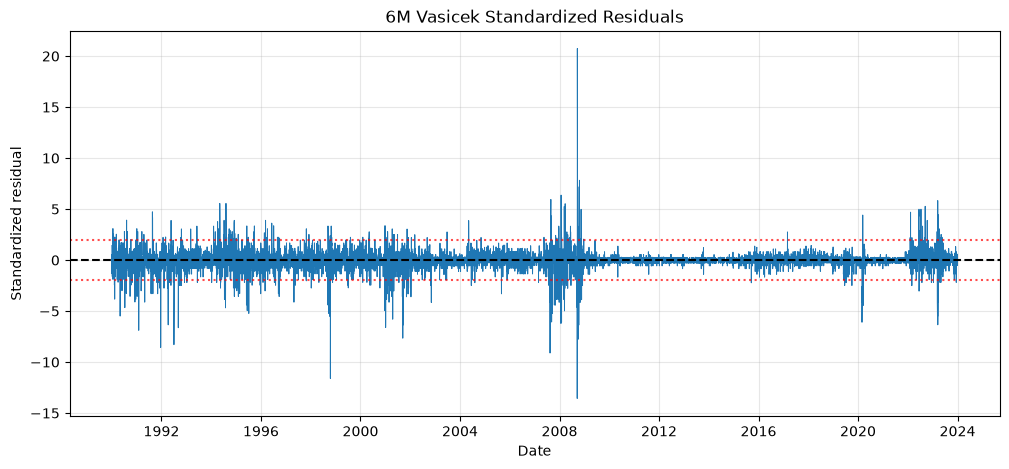

In [63]:
plt.figure(figsize=(12, 5))

plt.plot(
    validation_6m["Next_Date"],
    validation_6m[
        "Standardized_Residual"
    ],
    linewidth=0.7
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.axhline(
    2,
    color="red",
    linestyle=":",
    alpha=0.7
)

plt.axhline(
    -2,
    color="red",
    linestyle=":",
    alpha=0.7
)

plt.title(
    "6M Vasicek Standardized Residuals"
)

plt.xlabel("Date")
plt.ylabel("Standardized residual")
plt.grid(alpha=0.3)
plt.show()

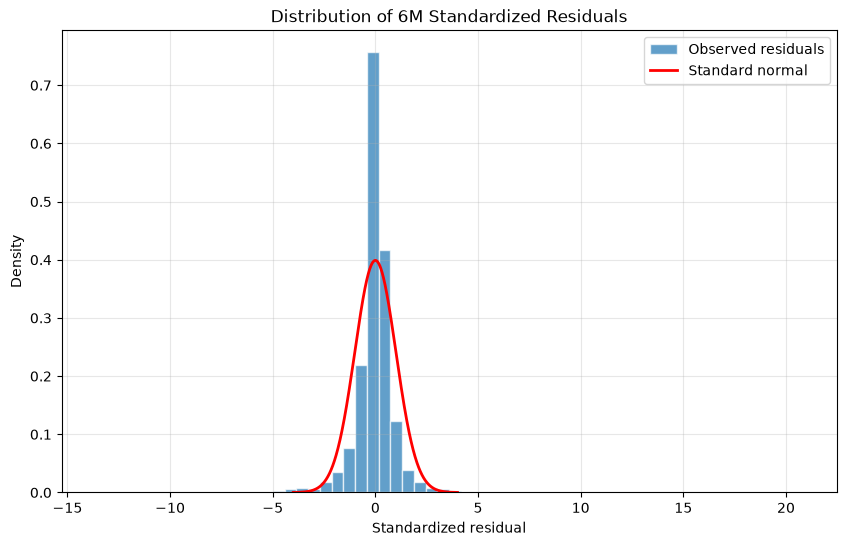

In [66]:
plt.figure(figsize=(10, 6))

plt.hist(
    standardized_residuals_6m,
    bins=60,
    density=True,
    alpha=0.7,
    edgecolor="white",
    label="Observed residuals"
)

x = np.linspace(
    -4,
    4,
    500
)

plt.plot(
    x,
    norm.pdf(x),
    color="red",
    linewidth=2,
    label="Standard normal"
)

plt.title(
    "Distribution of 6M Standardized Residuals"
)

plt.xlabel("Standardized residual")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

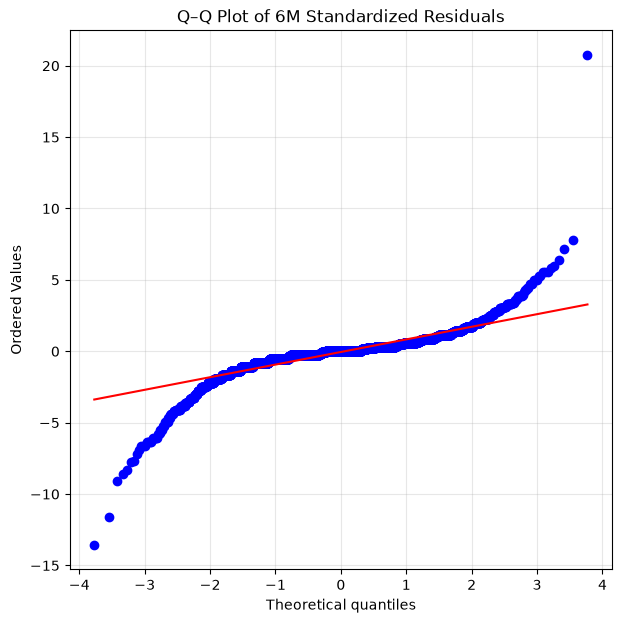

In [69]:
plt.figure(figsize=(7, 7))

probplot(
    standardized_residuals_6m,
    dist="norm",
    plot=plt
)

plt.title(
    "Q–Q Plot of 6M Standardized Residuals"
)

plt.grid(alpha=0.3)
plt.show()